In [79]:
import pandas as pd
import numpy as np

df = pd.read_csv("sales_prediction.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nNumerical Summary:")
display(df.describe())

Dataset Shape: (5005, 9)

First 5 Rows:


,Date,Product,Category,Region,Quantity,Unit_Price,Discount_Percent,Marketing_Spend,Sales
0,2025-06-24,Mouse,Accessories,Central,11,1033.44,3.93,16142.67,9937.94
1,2025-04-20,Mouse,Accessories,South,10,973.49,9.22,3669.56,3986.62
2,2025-10-07,Smartphone,Electronics,South,8,27250.86,19.80,4158.03,121875.93
3,2025-12-14,Monitor,Electronics,South,10,10436.98,8.84,17068.14,71722.04
4,2025-09-08,Printer,Office,North,12,12969.39,14.61,16170.03,155471.26



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5005 entries, 0 to 5004
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              5005 non-null   object 
 1   Product           5005 non-null   object 
 2   Category          5005 non-null   object 
 3   Region            5002 non-null   object 
 4   Quantity          5005 non-null   int64  
 5   Unit_Price        5002 non-null   float64
 6   Discount_Percent  5005 non-null   float64
 7   Marketing_Spend   5002 non-null   float64
 8   Sales             5005 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 352.0+ KB

Missing Values:
Date                0
Product             0
Category            0
Region              3
Quantity            0
Unit_Price          3
Discount_Percent    0
Marketing_Spend     3
Sales               0
dtype: int64

Duplicate Rows: 5

Numerical Summary:


,Quantity,Unit_Price,Discount_Percent,Marketing_Spend,Sales
count,5005.000000,5002.000000,5005.000000,5002.000000,5.005000e+03
mean,8.067133,17585.457372,9.974817,13443.355679,1.160761e+05
std,4.331983,17360.902324,5.750263,6601.916395,1.562027e+05
min,1.000000,765.260000,0.000000,2000.210000,5.000000e+02
25%,4.000000,3013.990000,5.080000,7719.357500,1.554720e+04
50%,8.000000,13189.355000,9.970000,13403.880000,5.201872e+04
75%,12.000000,25663.737500,14.870000,19011.770000,1.574456e+05
max,15.000000,63217.340000,20.000000,37161.828000,1.263050e+06


Products:
Product
Headphones    657
Monitor       652
Laptop        644
Keyboard      630
Smartphone    612
Tablet        609
Mouse         601
Printer       600
Name: count, dtype: int64

Categories:
Category
Electronics    2517
Accessories    1888
Office          600
Name: count, dtype: int64

Regions:
Region
South      1046
Central    1004
East        989
West        982
North       981
Name: count, dtype: int64


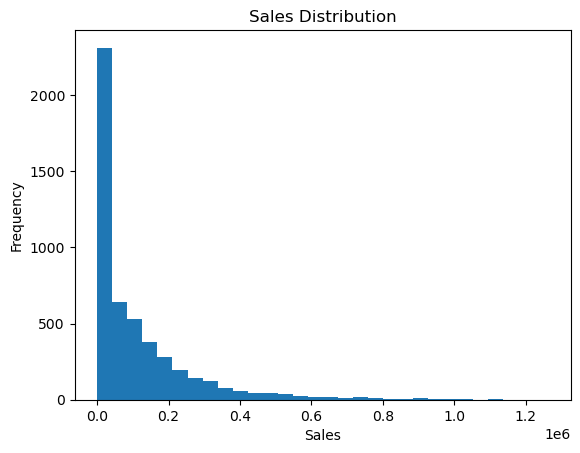

In [80]:
import matplotlib.pyplot as plt

print("Products:")
print(df["Product"].value_counts())

print("\nCategories:")
print(df["Category"].value_counts())

print("\nRegions:")
print(df["Region"].value_counts())

# Sales distribution
plt.hist(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [81]:
print("Numerical Columns:")

print("\nQuantity:")
print(df["Quantity"].describe())

print("\nUnit Price:")
print(df["Unit_Price"].describe())

print("\nDiscount:")
print(df["Discount_Percent"].describe())

print("\nMarketing Spend:")
print(df["Marketing_Spend"].describe())

print("\nSales:")
print(df["Sales"].describe())

Numerical Columns:

Quantity:
count    5005.000000
mean        8.067133
std         4.331983
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        15.000000
Name: Quantity, dtype: float64

Unit Price:
count     5002.000000
mean     17585.457372
std      17360.902324
min        765.260000
25%       3013.990000
50%      13189.355000
75%      25663.737500
max      63217.340000
Name: Unit_Price, dtype: float64

Discount:
count    5005.000000
mean        9.974817
std         5.750263
min         0.000000
25%         5.080000
50%         9.970000
75%        14.870000
max        20.000000
Name: Discount_Percent, dtype: float64

Marketing Spend:
count     5002.000000
mean     13443.355679
std       6601.916395
min       2000.210000
25%       7719.357500
50%      13403.880000
75%      19011.770000
max      37161.828000
Name: Marketing_Spend, dtype: float64

Sales:
count    5.005000e+03
mean     1.160761e+05
std      1.562027e+05
min      5.000000e+02
25%

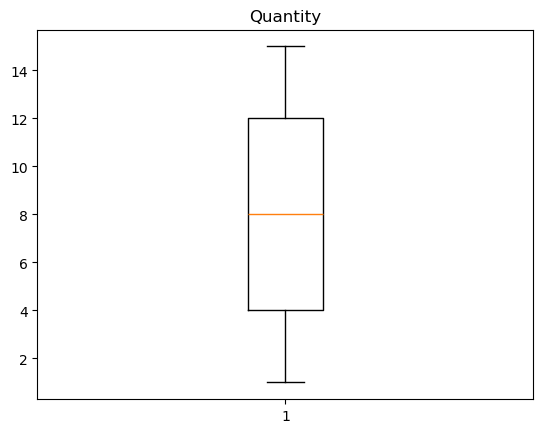

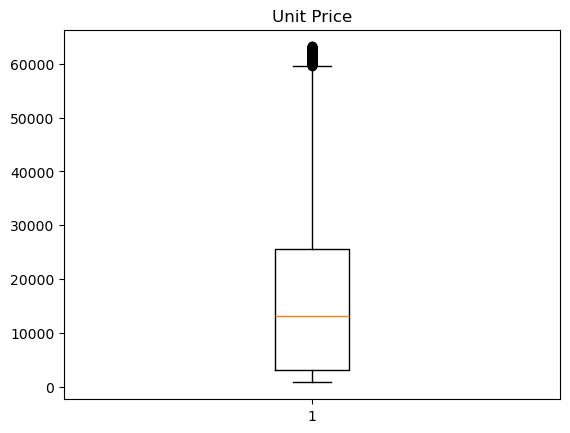

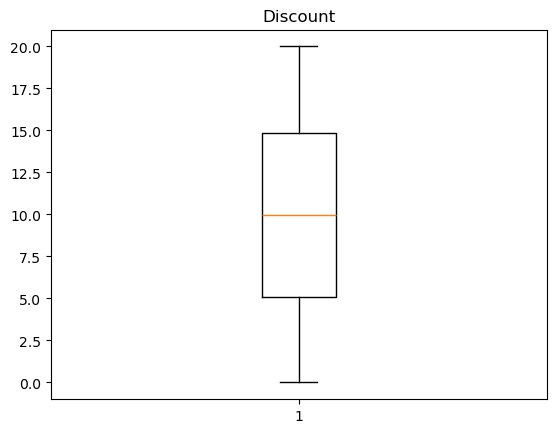

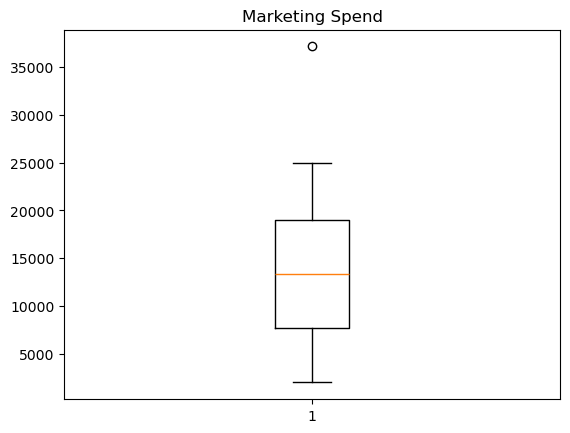

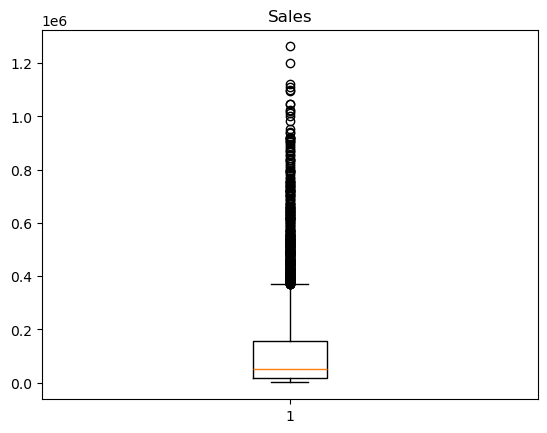

In [82]:
import matplotlib.pyplot as plt

plt.boxplot(df["Quantity"].dropna())
plt.title("Quantity")
plt.show()

plt.boxplot(df["Unit_Price"].dropna())
plt.title("Unit Price")
plt.show()

plt.boxplot(df["Discount_Percent"].dropna())
plt.title("Discount")
plt.show()

plt.boxplot(df["Marketing_Spend"].dropna())
plt.title("Marketing Spend")
plt.show()

plt.boxplot(df["Sales"].dropna())
plt.title("Sales")
plt.show()

In [83]:
correlation = df[
    ["Quantity", "Unit_Price", "Discount_Percent",
     "Marketing_Spend", "Sales"]
].corr()

print(correlation)

                  Quantity  Unit_Price  Discount_Percent  Marketing_Spend  \
Quantity          1.000000   -0.000117          0.009240        -0.012830   
Unit_Price       -0.000117    1.000000          0.015095        -0.024715   
Discount_Percent  0.009240    0.015095          1.000000         0.008537   
Marketing_Spend  -0.012830   -0.024715          0.008537         1.000000   
Sales             0.397114    0.730338         -0.045850        -0.006765   

                     Sales  
Quantity          0.397114  
Unit_Price        0.730338  
Discount_Percent -0.045850  
Marketing_Spend  -0.006765  
Sales             1.000000  


In [84]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (5005, 9)
After: (5000, 9)


In [85]:
print(df.isnull().sum())

Date                0
Product             0
Category            0
Region              3
Quantity            0
Unit_Price          3
Discount_Percent    0
Marketing_Spend     3
Sales               0
dtype: int64


In [86]:
df["Region"] = df["Region"].fillna(df["Region"].mode()[0])

df["Unit_Price"] = df["Unit_Price"].fillna(df["Unit_Price"].median())

df["Marketing_Spend"] = df["Marketing_Spend"].fillna(
    df["Marketing_Spend"].median()
)

print(df.isnull().sum())

Date                0
Product             0
Category            0
Region              0
Quantity            0
Unit_Price          0
Discount_Percent    0
Marketing_Spend     0
Sales               0
dtype: int64


In [87]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

df = df.drop("Date", axis=1)

print(df.head())

      Product     Category   Region  Quantity  Unit_Price  Discount_Percent  \
0       Mouse  Accessories  Central        11     1033.44              3.93   
1       Mouse  Accessories    South        10      973.49              9.22   
2  Smartphone  Electronics    South         8    27250.86             19.80   
3     Monitor  Electronics    South        10    10436.98              8.84   
4     Printer       Office    North        12    12969.39             14.61   

   Marketing_Spend      Sales  Year  Month  Day  DayOfWeek  
0         16142.67    9937.94  2025      6   24          1  
1          3669.56    3986.62  2025      4   20          6  
2          4158.03  121875.93  2025     10    7          1  
3         17068.14   71722.04  2025     12   14          6  
4         16170.03  155471.26  2025      9    8          0  


In [88]:
df = pd.get_dummies(
    df,
    columns=["Product", "Category", "Region"],
    drop_first=True
)

print(df.head())
print("\nNew Shape:", df.shape)

   Quantity  Unit_Price  Discount_Percent  Marketing_Spend      Sales  Year  \
0        11     1033.44              3.93         16142.67    9937.94  2025   
1        10      973.49              9.22          3669.56    3986.62  2025   
2         8    27250.86             19.80          4158.03  121875.93  2025   
3        10    10436.98              8.84         17068.14   71722.04  2025   
4        12    12969.39             14.61         16170.03  155471.26  2025   

   Month  Day  DayOfWeek  Product_Keyboard  ...  Product_Mouse  \
0      6   24          1             False  ...           True   
1      4   20          6             False  ...           True   
2     10    7          1             False  ...          False   
3     12   14          6             False  ...          False   
4      9    8          0             False  ...          False   

   Product_Printer  Product_Smartphone  Product_Tablet  Category_Electronics  \
0            False               False          

In [89]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (5000, 21)
y Shape: (5000,)


In [90]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Sales", axis=1)
y = df["Sales"]

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTraining Data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting Data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X Shape: (5000, 21)
y Shape: (5000,)

Training Data:
X_train: (4000, 21)
y_train: (4000,)

Testing Data:
X_test: (1000, 21)
y_test: (1000,)


In [91]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train the model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = model_lr.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 60629.12113945824
RMSE: 94632.41958364102
R²  : 0.6625841322306896


In [92]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train the model
model_dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

model_dt.fit(X_train, y_train)

# Predictions
y_pred_dt = model_dt.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("--------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Decision Tree Results
--------------------
MAE : 42505.28120457089
RMSE: 88262.51892618796
R²  : 0.7064796281407354


In [93]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model_rf2 = RandomForestRegressor(
    n_estimators=150,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model_rf2.fit(X_train, y_train)

# Test predictions
y_pred_rf2 = model_rf2.predict(X_test)

# Test performance
test_mae = mean_absolute_error(y_test, y_pred_rf2)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf2))
test_r2 = r2_score(y_test, y_pred_rf2)

# Training predictions
y_train_pred_rf2 = model_rf2.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred_rf2)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_rf2))
train_r2 = r2_score(y_train, y_train_pred_rf2)

print("Random Forest - Training")
print("------------------------")
print("MAE :", train_mae)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nRandom Forest - Testing")
print("-----------------------")
print("MAE :", test_mae)
print("RMSE:", test_rmse)
print("R²  :", test_r2)

Random Forest - Training
------------------------
MAE : 20304.148210518426
RMSE: 37793.40026983954
R²  : 0.940151783995601

Random Forest - Testing
-----------------------
MAE : 33363.96789453398
RMSE: 68549.65578995371
R²  : 0.8229499024044652


In [96]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train the model
model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model_xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = model_xgb.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

XGBoost Results
----------------
MAE : 34387.08202641113
RMSE: 70878.37801545906
R²  : 0.8107163269523521


In [98]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost"
    ],
    "MAE": [
        60629.12,
        42505.28,
        33694.53,
        33363.97,
        34387.08
    ],
    "RMSE": [
        94632.42,
        88262.52,
        69555.68,
        68549.66,
        70878.38
    ],
    "R2": [
        0.663,
        0.706,
        0.818,
        0.823,
        0.811
    ]
})

print("Final Model Comparison:")
display(results.sort_values("R2", ascending=False))

Final Model Comparison:


,Model,MAE,RMSE,R2
3,Tuned Random Forest,33363.97,68549.66,0.823
2,Random Forest,33694.53,69555.68,0.818
4,XGBoost,34387.08,70878.38,0.811
1,Decision Tree,42505.28,88262.52,0.706
0,Linear Regression,60629.12,94632.42,0.663


In [101]:
import joblib

joblib.dump(X.columns.tolist(), "sales_features.pkl")

print("sales_features.pkl created successfully!")

sales_features.pkl created successfully!


In [102]:
import joblib

joblib.dump(model_rf2, "sales_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
